REGIONES Y FRONTERAS

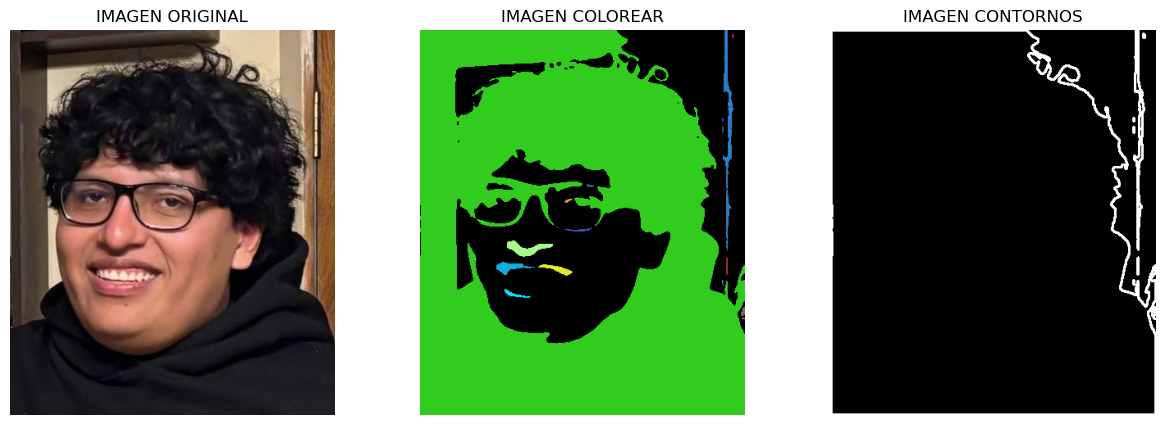

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('PDI2026/Clase1/chanki.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# COMBINACIONES DE TECNICAS PARA PREPARAR LA IMAGEN
blur = cv2.GaussianBlur(gray, (7,7), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# ENCONTRAR LAS REGIONES
num_l, label = cv2.connectedComponents(binary)

# IDENTIFICAR POR COLORES
color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)

# FONDO NEGRO
color[0] = [0,0,0]
colorear = color[label]

# ENCONTRAR FRONTERAS
contornos,_ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contornos_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255, 2)

plt.figure(figsize=(15,5))

plt.subplot(131)
plt.title("IMAGEN ORIGINAL")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(132)
plt.title("IMAGEN COLOREAR")
plt.imshow(colorear)
plt.axis('off')

plt.subplot(133)
plt.title("IMAGEN CONTORNOS")
plt.imshow(contornos_fin, cmap='gray')
plt.axis('off')

plt.show()

CONTEO

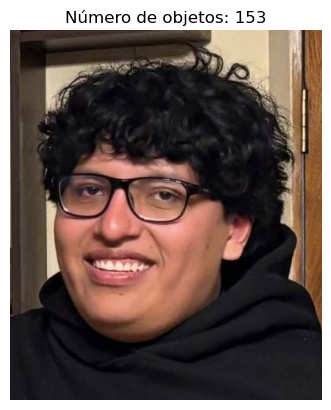

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binario = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    
    # Usar componentes conectados de OpenCV
    num_labels, labels = cv2.connectedComponents(binario)
    num_obj = num_labels - 1  # Restar 1 porque el fondo cuenta como etiqueta 0
    return num_obj

imagen = cv2.imread('PDI2026/Clase1/chanki.jpg')
conteo = contar_elementos(imagen)

# Convertir a RGB para mostrar correctamente
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

plt.imshow(imagen_rgb)
plt.title(f'Número de objetos: {conteo}')
plt.axis('off')
plt.show()